# Feature Engineering para Demanda de Planos de Saúde

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

No notebook anterior trabalhamos o lado **assistencial**: chegadas ao pronto atendimento, com clima, epidemia e calendário. As variáveis vinham de fora do hospital e o desafio era encontrar a **defasagem** certa.

Aqui trocamos de lado. Na **operadora**, a demanda não é dirigida pelo tempo nem pela epidemia apenas: ela é dirigida pelo **próprio desenho do produto e pela operação**. O beneficiário liga porque a mensalidade venceu. O prestador solicita autorização porque o contrato dele acabou de ser renovado. O volume dispara porque a área de comunicação disparou um SMS na terça-feira. Nada disso está no calendário nacional, e tudo isso está no sistema da operadora.

E aparece um tema que no hospital era secundário e aqui é central: **os dados são do beneficiário**. Idade, condição crônica, procedimento solicitado e histórico de utilização são dados pessoais, e alguns deles são **dados pessoais sensíveis de saúde** na definição da LGPD. Isso muda a engenharia de variáveis de forma concreta, e uma das perguntas que vamos responder com número é: **quanto de acurácia custa proteger o dado do beneficiário?**

**Caso de estudo:** o **volume diário de solicitações de autorização prévia por especialidade** (Seção 14.4 da apostila). A análise de autorização prévia é a etapa em que a operadora avalia se um procedimento solicitado será coberto, e o dimensionamento da equipe de auditoria médica depende diretamente dessa previsão. O dado tem a estrutura de **painel**: várias especialidades acompanhadas ao longo do tempo, exatamente como as carteiras do notebook de boosting.

**Ao final desta aula você será capaz de:**

1. Construir as **variáveis operacionais** da Seção 11.4 e medir o efeito de cada uma.
2. Criar **agregações por entidade** em um painel, sem vazamento.
3. Quantificar o **custo em acurácia** de cada nível de proteção de dado pessoal, e levar esse número para a discussão com o encarregado de dados.
4. Aplicar o checklist de **governança e LGPD** (Seção 11.5) à decisão de quais variáveis criar.
5. Escrever um **pipeline de features de produção** (Seção 11.6), com artefato versionado e teste de consistência entre treino e produção.
6. Monitorar **desvio de distribuição** com o índice PSI, e saber quando o desvio importa e quando não importa.


## 0. Preparação do ambiente


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "sklearn", "lightgbm", "ipywidgets"])

import warnings, json, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.inspection import permutation_importance

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto.")

Ambiente pronto.


## O problema: autorização prévia

Quando um médico solicita uma ressonância, uma cirurgia eletiva ou uma internação, a operadora precisa avaliar a solicitação antes de autorizar. Essa etapa, a **autorização prévia**, envolve auditoria médica, checagem contratual e, em parte dos casos, junta médica. É trabalho humano qualificado, com prazo regulatório para resposta.

Prever o volume de solicitações do dia seguinte, **por especialidade**, resolve quatro problemas de gestão:

1. **Dimensionar a auditoria médica.** Um pico de solicitações de ortopedia exige auditor de ortopedia, não um auditor genérico.
2. **Cumprir prazo regulatório.** Fila de autorização acumulada vira prazo estourado, reclamação e sanção.
3. **Antecipar custo assistencial.** O que é autorizado hoje vira despesa nas semanas seguintes, e alimenta a projeção de sinistralidade.
4. **Detectar comportamento atípico.** Uma especialidade que foge do previsto de forma persistente é candidata a auditoria de padrão de utilização.

A base tem **dois anos** e **8 especialidades**, no formato de painel (uma linha por dia e por especialidade). Os efeitos embutidos são deliberadamente **operacionais**, e não climáticos:

| Fator                                  | Efeito embutido                                                                     |
| -------------------------------------- | ----------------------------------------------------------------------------------- |
| Dia da semana                          | sábado e domingo quase parados, segunda-feira cheia                                 |
| Feriado                                | queda quase total                                                                   |
| **Janela de vencimento (dias 1 a 10)** | início do mês concentra solicitações                                                |
| **Fim de trimestre**                   | empresas e prestadores antecipam procedimentos antes do fechamento                  |
| **Campanha de comunicação**            | disparo de SMS ou e-mail eleva a procura por alguns dias                            |
| Sazonalidade por especialidade         | pneumologia no inverno, ortopedia no verão, oncologia estável                       |
| **Onda clínica latente**               | surtos que elevam o volume por semanas, com intensidade diferente por especialidade |
| Perfil do beneficiário                 | durante as ondas, o perfil fica **mais velho e mais crônico**                       |
| Ruído de Poisson                       | contagem tem aleatoriedade irredutível                                              |

A penúltima linha é a que sustenta a discussão de LGPD. O perfil dos solicitantes **carrega informação sobre o estado da demanda**, e é justamente o tipo de dado que a proteção de dados pessoais restringe.


In [2]:
ESPECIALIDADES = {
    # nome: (base/dia, mes de pico, amplitude sazonal, % alta complexidade, taxa de negativa)
    "Ortopedia":         (34, 1, 0.22, 0.22, 0.11),
    "Cardiologia":       (26, 7, 0.18, 0.30, 0.08),
    "Oncologia":         (12, 0, 0.05, 0.62, 0.05),
    "Pneumologia":       (18, 7, 0.38, 0.24, 0.09),
    "Ginecologia":       (30, 3, 0.12, 0.14, 0.07),
    "Oftalmologia":      (28, 10, 0.15, 0.10, 0.13),
    "Gastroenterologia": (22, 5, 0.10, 0.20, 0.10),
    "Neurologia":        (16, 6, 0.12, 0.34, 0.12),
}
FERIADOS = pd.to_datetime([
    "2024-01-01", "2024-02-12", "2024-02-13", "2024-03-29", "2024-04-21", "2024-05-01", "2024-05-30",
    "2024-09-07", "2024-10-12", "2024-11-02", "2024-11-15", "2024-11-20", "2024-12-25",
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18", "2025-04-21", "2025-05-01", "2025-06-19",
    "2025-09-07", "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20", "2025-12-25"])
CAMPANHAS = [("2024-04-08", 5), ("2024-09-16", 5), ("2025-03-10", 5),
             ("2025-08-11", 5), ("2025-10-20", 5)]


def gerar_autorizacoes(dias=730, semente=SEMENTE):
    """Painel de solicitacoes de autorizacao previa: dia x especialidade."""
    g = np.random.default_rng(semente)
    datas = pd.date_range("2024-01-01", periods=dias, freq="D")
    dia_semana = datas.dayofweek.to_numpy()
    dia_mes = datas.day.to_numpy()
    mes = datas.month.to_numpy()
    feriado = np.isin(datas, FERIADOS).astype(float)

    perfil_semana = np.array([1.28, 1.10, 1.05, 1.02, 0.95, 0.35, 0.12])   # fim de semana quase parado
    janela_vencimento = ((dia_mes >= 1) & (dia_mes <= 10)).astype(float)
    fim_trimestre = (np.isin(mes, [3, 6, 9, 12]) & (dia_mes >= 25)).astype(float)
    campanha = np.zeros(dias)
    for inicio, duracao in CAMPANHAS:
        i = (pd.Timestamp(inicio) - datas[0]).days
        campanha[i:i + duracao] = 1.0

    # Onda clinica latente: sobe de repente e decai por semanas. Nao esta em nenhum calendario.
    onda = np.zeros(dias)
    estado = 0.0
    for d in range(dias):
        if g.random() < 0.012:
            estado += g.uniform(0.18, 0.45)
        estado *= 0.95
        onda[d] = estado

    blocos = []
    for nome, (base, pico, amplitude, pct_alta, taxa_negativa) in ESPECIALIDADES.items():
        sazonal = 1 + amplitude * np.cos(2 * np.pi * (datas.dayofyear.to_numpy() - pico * 30) / 365)
        sensibilidade = 1.6 if nome in ("Pneumologia", "Cardiologia") else (0.4 if nome == "Oncologia" else 1.0)

        intensidade = (base * perfil_semana[dia_semana] * sazonal
                       * (1 + 0.22 * janela_vencimento + 0.30 * fim_trimestre + 0.35 * campanha)
                       * (1 - 0.85 * feriado)
                       * (1 + sensibilidade * onda)
                       * (1 + 0.05 * np.arange(dias) / dias * 4))
        intensidade = np.clip(intensidade, 0.3, None)
        solicitacoes = g.poisson(intensidade)

        # Perfil do beneficiario: durante a onda, os solicitantes ficam mais velhos e mais cronicos
        idade_media = (44 + 16 * (nome == "Oncologia") + 10 * (nome == "Cardiologia")
                       - 6 * (nome == "Ginecologia") + 11 * onda * sensibilidade + g.normal(0, 0.8, dias))
        pct_exato = np.clip(0.18 + 0.010 * (idade_media - 44) + g.normal(0, 0.012, dias), 0, 1)
        # A versao ANONIMIZADA e agregada em faixas de 5 pontos percentuais, com ruido de agregacao
        pct_60mais = np.round(np.clip(pct_exato + g.normal(0, 0.030, dias), 0, 1) / 0.05) * 0.05
        pct_cronico = np.clip(0.22 + 1.3 * onda * sensibilidade + g.normal(0, 0.012, dias), 0, 1)
        pct_alta_cpx = np.clip(pct_alta + 0.35 * onda * sensibilidade + g.normal(0, 0.02, dias), 0, 1)

        blocos.append(pd.DataFrame({
            "data": datas, "especialidade": nome, "solicitacoes": solicitacoes,
            "intensidade": intensidade,
            "idade_media": idade_media.round(1), "pct_60mais": pct_60mais.round(4),
            "pct_cronico": pct_cronico.round(4), "pct_alta_complexidade": pct_alta_cpx.round(4),
            "taxa_negativa": np.clip(taxa_negativa + g.normal(0, 0.012, dias), 0, 1).round(4)}))

    return pd.concat(blocos, ignore_index=True)


painel = gerar_autorizacoes()
total_dia = painel.groupby("data")["solicitacoes"].sum()

print(f"Painel: {len(painel)} linhas ({painel.data.nunique()} dias x {painel.especialidade.nunique()} especialidades)")
print(f"Periodo: {painel.data.min():%d/%m/%Y} a {painel.data.max():%d/%m/%Y}")
print(f"Media por dia e especialidade: {painel.solicitacoes.mean():.1f} solicitacoes")
print(f"Total da operadora por dia: media {total_dia.mean():.0f}, "
      f"minimo {total_dia.min():.0f}, maximo {total_dia.max():.0f}")
painel.head(3)

Painel: 5840 linhas (730 dias x 8 especialidades)
Periodo: 01/01/2024 a 30/12/2025
Media por dia e especialidade: 24.2 solicitacoes
Total da operadora por dia: media 194, minimo 2, maximo 486


,data,especialidade,solicitacoes,intensidade,idade_media,pct_60mais,pct_cronico,pct_alta_complexidade,taxa_negativa
0,2024-01-01,Ortopedia,5,9.502447,42.8,0.15,0.2162,0.2068,0.1220
1,2024-01-02,Ortopedia,46,54.537456,45.3,0.20,0.1981,0.2429,0.1065
2,2024-01-03,Ortopedia,55,52.147979,43.7,0.20,0.2083,0.1991,0.0921


> **Lendo o resultado.** O painel tem **5.840 linhas**, uma para cada combinação de dia e especialidade, com média de **23 solicitações por dia por especialidade** e um total de operadora que oscila entre **poucas dezenas e mais de 450 por dia**.
>
> Essa amplitude enorme no total diário já antecipa o principal fator: a diferença entre um dia útil e um domingo. Nenhuma sofisticação de modelo importa se a variável `dia_semana` não estiver lá.
>
> Repare também que a tabela traz colunas de **perfil do beneficiário** (`idade_media`, `pct_60mais`, `pct_cronico`) que descrevem quem solicitou naquele dia. Elas são o objeto da discussão de LGPD mais adiante, e por ora vale registrar uma regra que já conhecemos: essas colunas descrevem o **próprio dia que queremos prever**, então usá-las diretamente seria vazamento. Só entrarão no modelo **defasadas**.


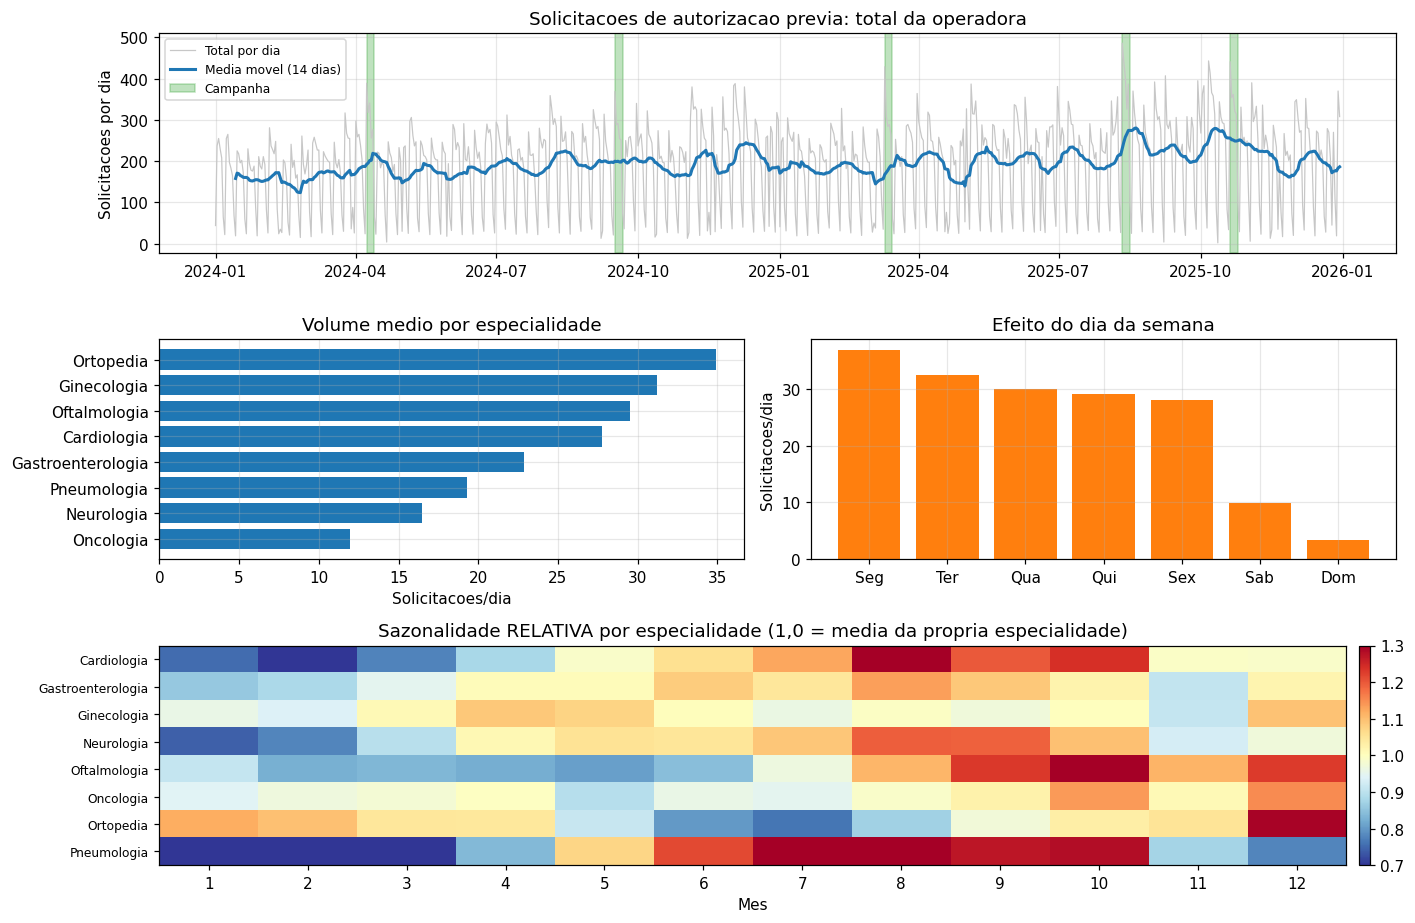

In [3]:
fig = plt.figure(figsize=(13, 8.5))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax2 = plt.subplot2grid((3, 2), (1, 0))
ax3 = plt.subplot2grid((3, 2), (1, 1))
ax4 = plt.subplot2grid((3, 2), (2, 0), colspan=2)

ax1.plot(total_dia.index, total_dia.values, color="#c7c7c7", lw=0.8, label="Total por dia")
ax1.plot(total_dia.index, total_dia.rolling(14).mean(), color="#1f77b4", lw=2, label="Media movel (14 dias)")
for i, (inicio, duracao) in enumerate(CAMPANHAS):
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(inicio) + pd.Timedelta(days=duracao),
                color="#2ca02c", alpha=0.30, label="Campanha" if i == 0 else None)
ax1.set_title("Solicitacoes de autorizacao previa: total da operadora")
ax1.set_ylabel("Solicitacoes por dia"); ax1.legend(fontsize=8)

por_esp = painel.groupby("especialidade")["solicitacoes"].mean().sort_values()
ax2.barh(por_esp.index, por_esp.values, color="#1f77b4")
ax2.set_title("Volume medio por especialidade"); ax2.set_xlabel("Solicitacoes/dia")

nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
por_dia = painel.groupby(painel.data.dt.dayofweek)["solicitacoes"].mean()
ax3.bar(nomes_dias, por_dia.values, color="#ff7f0e")
ax3.set_title("Efeito do dia da semana"); ax3.set_ylabel("Solicitacoes/dia")

pivo = (painel.assign(mes=painel.data.dt.month)
        .pivot_table(index="especialidade", columns="mes", values="solicitacoes", aggfunc="mean"))
pivo_rel = pivo.div(pivo.mean(axis=1), axis=0)
im = ax4.imshow(pivo_rel.values, aspect="auto", cmap="RdYlBu_r", vmin=0.7, vmax=1.3)
ax4.set_yticks(range(len(pivo_rel))); ax4.set_yticklabels(pivo_rel.index, fontsize=8)
ax4.set_xticks(range(12)); ax4.set_xticklabels(range(1, 13))
ax4.set_title("Sazonalidade RELATIVA por especialidade (1,0 = media da propria especialidade)")
ax4.set_xlabel("Mes"); ax4.grid(False)
plt.colorbar(im, ax=ax4, fraction=0.03, pad=0.01)

plt.tight_layout(); plt.show()

> **Lendo os gráficos.** Quatro leituras que orientam a construção de variáveis.
>
> **No topo**, o total diário com as janelas de campanha destacadas em verde. Duas coisas saltam: a série tem um **serrilhado violento**, que é o ciclo semanal, e a média móvel apresenta **corcovas de semanas** que não coincidem com as campanhas. Aquelas corcovas são a onda clínica latente, e nenhuma variável de calendário vai explicá-las.
>
> **No meio à esquerda**, o volume por especialidade: ortopedia e ginecologia lideram, oncologia é a menor. Escalas muito diferentes no mesmo painel, o que reforça a importância de incluir a **identidade da especialidade** como variável.
>
> **No meio à direita**, o efeito do dia da semana, que é brutal: de segunda-feira para domingo o volume cai mais de 80%. Este é o fator dominante do problema.
>
> **Embaixo**, o mapa de calor da sazonalidade **relativa**, com cada especialidade normalizada pela sua própria média. Aqui aparece o que a média geral esconde: **pneumologia e cardiologia sobem no inverno**, **ortopedia sobe no verão**, e **oncologia é praticamente plana**. Um modelo com uma única variável de sazonalidade para todas as especialidades erraria os três casos. O que faz o modelo acertar é a **interação** entre especialidade e mês, e é por isso que modelos de árvore vão bem aqui.


## 11.4 Features operacionais de plano de saúde

Esta é a família que **não existe no hospital** e que é a mais valiosa na operadora, porque descreve o funcionamento do próprio negócio. A apostila lista quatro grupos, e todos aparecem aqui:

| Feature                                      | O que captura                                                                          |
| -------------------------------------------- | -------------------------------------------------------------------------------------- |
| **Dia de vencimento da mensalidade**         | o início do mês concentra contato, cobrança e regularização, e junto vem a solicitação |
| **Janela de campanha**                       | disparo de SMS ou e-mail em massa produz um pico de poucos dias                        |
| **Ciclo de renovação de contrato**           | contratos empresariais concentram movimentação no mês de aniversário                   |
| **Fim de trimestre**                         | prestadores e empresas antecipam procedimentos antes do fechamento contábil            |
| **Categoria e complexidade do procedimento** | ressonância e cirurgia eletiva têm dinâmica diferente de consulta                      |

Todas têm a mesma característica agradável: são **conhecidas com antecedência**. A operadora sabe quando dispara a campanha, sabe o calendário de vencimento e sabe quando fecha o trimestre. Diferente do clima, que precisa de previsão meteorológica, essas variáveis estão disponíveis com meses de folga.

Antes de escrever a coluna, vale medir o efeito.


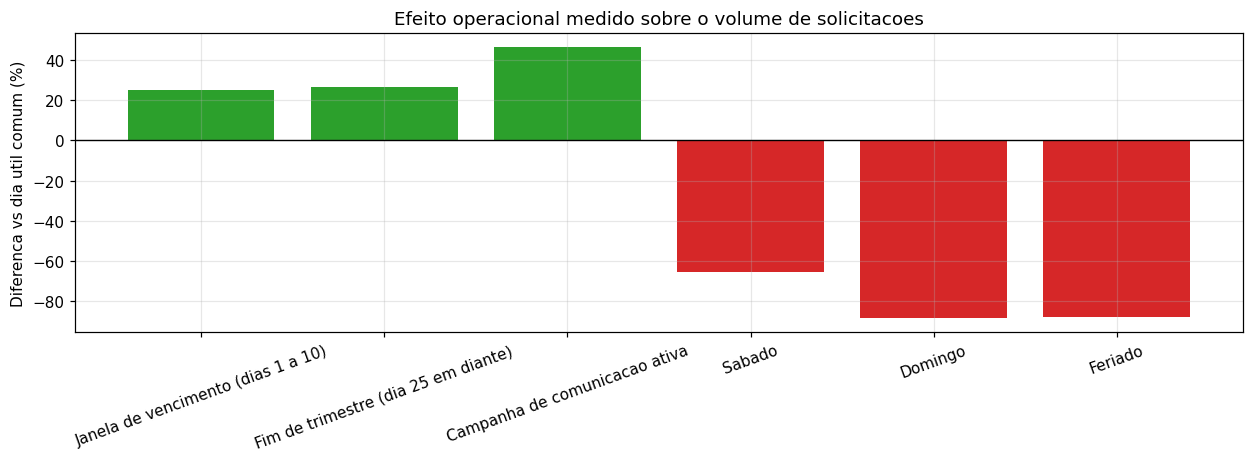

,situacao,dias observados,media de solicitacoes,efeito vs dia util comum (%)
0,Dia util comum (referencia),2280,28.8,0.0
1,Janela de vencimento (dias 1 a 10),1328,36.1,25.1
2,Fim de trimestre (dia 25 em diante),256,36.5,26.8
3,Campanha de comunicacao ativa,200,42.2,46.6
4,Sabado,832,9.9,-65.5
5,Domingo,832,3.3,-88.5
6,Feriado,208,3.5,-87.7


In [4]:
def marcar_operacionais(datas):
    """Marca as janelas operacionais da operadora. Todas conhecidas com antecedencia."""
    d = pd.DatetimeIndex(datas)
    janela_vencimento = ((d.day >= 1) & (d.day <= 10)).astype(int)
    fim_trimestre = ((d.month.isin([3, 6, 9, 12])) & (d.day >= 25)).astype(int)
    campanha = np.zeros(len(d), dtype=int)
    for inicio, duracao in CAMPANHAS:
        dentro = (d >= pd.Timestamp(inicio)) & (d < pd.Timestamp(inicio) + pd.Timedelta(days=duracao))
        campanha |= dentro.astype(int)
    return janela_vencimento, fim_trimestre, campanha


venc, fimtri, camp = marcar_operacionais(painel.data)
aux = painel.assign(janela_vencimento=venc, fim_trimestre=fimtri, campanha=camp,
                    eh_feriado=painel.data.isin(FERIADOS).astype(int),
                    dia_semana=painel.data.dt.dayofweek)

comum = ((aux.janela_vencimento == 0) & (aux.fim_trimestre == 0) & (aux.campanha == 0) &
         (aux.eh_feriado == 0) & (aux.dia_semana < 5))
base = aux[comum].solicitacoes.mean()

cenarios = [
    ("Dia util comum (referencia)", comum),
    ("Janela de vencimento (dias 1 a 10)", (aux.janela_vencimento == 1) & (aux.dia_semana < 5) & (aux.eh_feriado == 0)),
    ("Fim de trimestre (dia 25 em diante)", (aux.fim_trimestre == 1) & (aux.dia_semana < 5) & (aux.eh_feriado == 0)),
    ("Campanha de comunicacao ativa", (aux.campanha == 1) & (aux.dia_semana < 5) & (aux.eh_feriado == 0)),
    ("Sabado", aux.dia_semana == 5),
    ("Domingo", aux.dia_semana == 6),
    ("Feriado", aux.eh_feriado == 1),
]
efeitos = pd.DataFrame([{"situacao": nome, "dias observados": int(m.sum()),
                         "media de solicitacoes": round(aux[m].solicitacoes.mean(), 1),
                         "efeito vs dia util comum (%)": round(100 * (aux[m].solicitacoes.mean() - base) / base, 1)}
                        for nome, m in cenarios])

fig, ax = plt.subplots(figsize=(11.5, 4.3))
valores = efeitos["efeito vs dia util comum (%)"][1:]
cores = ["#2ca02c" if v > 0 else "#d62728" for v in valores]
ax.bar(efeitos["situacao"][1:], valores, color=cores)
ax.axhline(0, color="black", lw=0.9)
ax.set_title("Efeito operacional medido sobre o volume de solicitacoes")
ax.set_ylabel("Diferenca vs dia util comum (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

efeitos

> **Lendo o gráfico.** Os efeitos operacionais são **grandes**, e alguns deles maiores do que qualquer efeito climático do notebook anterior.
>
> - **Campanha de comunicação: +45,6%.** É o maior efeito positivo da base. Um disparo em massa quase duplica a demanda de autorização por alguns dias. E note que é um efeito **provocado pela própria operadora**, ou seja, totalmente conhecido de antemão. Não incluir essa variável é jogar fora informação que a área de marketing tem na agenda.
> - **Fim de trimestre: +26,0%** e **janela de vencimento: +25,3%.** Dois efeitos de calendário administrativo, ambos previsíveis com um ano de antecedência.
> - **Feriado: -88,1%** e **domingo: -88,5%.** A operação praticamente para. Este é o efeito dominante e o que qualquer modelo captura primeiro.
> - **Sábado: -65,6%.** Queda forte, mas menor que a de domingo, e é por isso que `eh_fim_semana` como variável binária única seria pior do que `dia_semana`: sábado e domingo **não são o mesmo dia**.
>
> Uma observação de método que vale para qualquer projeto: estes efeitos foram medidos **condicionando em dia útil e sem feriado**. Se comparássemos a média dos dias de campanha com a média geral, sem esse cuidado, o resultado dependeria de quantos fins de semana caíram dentro da janela de campanha. **Comparação de médias sem controle é a forma mais fácil de medir errado.**


## Agregações por entidade: o que o painel permite e a série única não permite

Quando os dados têm estrutura de painel, abre-se uma família de variáveis que não existe em uma série isolada: as **agregações por entidade**. A ideia é responder, para cada linha, a perguntas de contexto:

- **Sobre a própria entidade:** como esta especialidade vinha se comportando? (`lag1`, `lag7`, `media7`, `media28`)
- **Sobre o todo:** como a operadora inteira vinha se comportando? (`total_operadora_lag1`, `total_operadora_media7`)
- **Sobre a posição relativa:** que fatia do total esta especialidade costuma representar? (`share_especialidade`)
- **Sobre o desvio:** esta especialidade está acima ou abaixo do seu próprio normal? (`desvio_vs_media28`)

As duas últimas são especialmente úteis e frequentemente esquecidas. Uma **razão** entre o valor recente e a média de referência é uma variável **adimensional**, que significa a mesma coisa para a oncologia (12 solicitações por dia) e para a ortopedia (34). Isso ajuda o modelo a transferir aprendizado entre entidades de escalas diferentes, e é o que a Seção 11 chama de normalização implícita.

O agregado da operadora inteira tem um papel específico aqui: como a **onda clínica é comum a todas as especialidades**, o total de ontem carrega informação sobre o estado atual da onda que a série de uma única especialidade, mais ruidosa, não carrega tão bem.

E vale repetir a regra de ouro do notebook de boosting, agora com duas armadilhas técnicas que merecem atenção especial, porque são a origem do bug mais comum em painel:

**Armadilha 1: a janela móvel atravessa a fronteira do grupo.** Escrever `grupo["x"].shift(1).rolling(7).mean()` parece correto e não é. O `shift` respeita o grupo, mas o `rolling` que vem depois opera sobre a série **achatada**, então nas primeiras linhas de cada especialidade ele mistura os últimos dias da especialidade anterior. A forma correta é `grupo["x"].transform(lambda s: s.shift(1).rolling(7).mean())`, que aplica a operação inteira **dentro** de cada grupo.

**Armadilha 2: o alinhamento por índice.** Ao atribuir uma Series a uma coluna, o pandas alinha **por rótulo de índice**, não por posição. Se o índice do resultado não for o mesmo do DataFrame, os valores vão para as linhas erradas silenciosamente, sem erro nenhum. Por isso o `reset_index(drop=True)` logo depois da ordenação.

As duas armadilhas produzem features contaminadas que **não geram exceção**, não aparecem como NaN e passam despercebidas na avaliação. O teste de consistência da Seção 11.6, no fim deste notebook, é justamente o instrumento que as detecta.


In [5]:
def construir_features(painel):
    """Pipeline unico de features. A MESMA funcao roda no treino e na producao."""
    df = painel.sort_values(["especialidade", "data"]).reset_index(drop=True)
    grupo = df.groupby("especialidade", sort=False)
    d = df["data"]

    # --- calendario
    df["dia_semana"] = d.dt.dayofweek
    df["dia_mes"] = d.dt.day
    df["mes"] = d.dt.month
    df["semana_mes"] = (d.dt.day - 1) // 7 + 1
    df["eh_feriado"] = d.isin(FERIADOS).astype(int)
    df["eh_vespera"] = d.isin(pd.DatetimeIndex(FERIADOS) - pd.Timedelta(days=1)).astype(int)

    # --- operacionais da operadora
    venc, fimtri, camp = marcar_operacionais(d)
    df["janela_vencimento"], df["fim_trimestre"], df["campanha"] = venc, fimtri, camp
    df["dias_uteis_restantes_mes"] = d.dt.days_in_month - d.dt.day

    # --- agregacoes por ENTIDADE (a propria especialidade), sempre com shift DENTRO do grupo
    for L in (1, 2, 7):
        df[f"lag{L}"] = grupo["solicitacoes"].shift(L)
    df["media7"] = grupo["solicitacoes"].transform(lambda s: s.shift(1).rolling(7).mean())
    df["media28"] = grupo["solicitacoes"].transform(lambda s: s.shift(1).rolling(28).mean())
    df["dp7"] = grupo["solicitacoes"].transform(lambda s: s.shift(1).rolling(7).std())

    # --- agregacoes do TODO e posicao relativa
    total = painel.groupby("data")["solicitacoes"].sum()
    df["total_operadora_lag1"] = df["data"].map(total.shift(1))
    df["total_operadora_media7"] = df["data"].map(total.shift(1).rolling(7).mean())
    df["share_especialidade"] = df["media28"] / df["total_operadora_media7"]
    df["desvio_vs_media28"] = df["lag1"] / df["media28"]

    # --- perfil do beneficiario, em dois niveis de granularidade (ver a secao de LGPD)
    df["pct60_media7"] = grupo["pct_60mais"].transform(lambda s: s.shift(1).rolling(7).mean())
    df["idade_media7"] = grupo["idade_media"].transform(lambda s: s.shift(1).rolling(7).mean())
    df["cronico_media7"] = grupo["pct_cronico"].transform(lambda s: s.shift(1).rolling(7).mean())
    df["altacpx_media7"] = grupo["pct_alta_complexidade"].transform(lambda s: s.shift(1).rolling(7).mean())
    df["negativa_media28"] = grupo["taxa_negativa"].transform(lambda s: s.shift(1).rolling(28).mean())

    return df.dropna().reset_index(drop=True)


BLOCO_ESPECIALIDADE = ["especialidade"]
BLOCO_CALENDARIO = ["dia_semana", "dia_mes", "mes", "semana_mes", "eh_feriado", "eh_vespera"]
BLOCO_OPERACIONAL = ["janela_vencimento", "fim_trimestre", "campanha", "dias_uteis_restantes_mes"]
BLOCO_AGREGADO = ["total_operadora_lag1", "total_operadora_media7", "share_especialidade", "desvio_vs_media28"]
BLOCO_HISTORICO = ["lag1", "lag2", "lag7", "media7", "media28", "dp7"]
PERFIL_ANONIMO = ["pct60_media7"]
PERFIL_DETALHADO = ["idade_media7", "cronico_media7", "altacpx_media7", "negativa_media28"]

dados = construir_features(painel)
dados["especialidade"] = dados["especialidade"].astype("category")

corte1 = dados["data"].quantile(0.70)
corte2 = dados["data"].quantile(0.85)
treino = dados[dados.data <= corte1]
validacao = dados[(dados.data > corte1) & (dados.data <= corte2)]
teste = dados[dados.data > corte2]
y_teste = teste["solicitacoes"].values

print(f"Linhas apos as defasagens: {len(dados)} (perdemos os 28 primeiros dias de cada especialidade)")
print(f"TREINO    {len(treino):5d}  ate {corte1:%d/%m/%Y}")
print(f"VALIDACAO {len(validacao):5d}  ate {corte2:%d/%m/%Y}")
print(f"TESTE     {len(teste):5d}  de {teste.data.min():%d/%m/%Y} a {teste.data.max():%d/%m/%Y}")
print()

def metricas(y_real, y_prev):
    y_real = np.asarray(y_real, float); y_prev = np.asarray(y_prev, float)
    erro = y_real - y_prev
    return np.mean(np.abs(erro)), np.sqrt(np.mean(erro ** 2))

referencias = pd.DataFrame([
    {"referencia": "Media dos ultimos 28 dias", **dict(zip(("MAE", "RMSE"),
        np.round(metricas(y_teste, teste["media28"]), 3)))},
    {"referencia": "Mesmo dia da semana anterior (lag 7)", **dict(zip(("MAE", "RMSE"),
        np.round(metricas(y_teste, teste["lag7"]), 3)))},
    {"referencia": "ORACULO (conhece a intensidade)", **dict(zip(("MAE", "RMSE"),
        np.round(metricas(y_teste, teste["intensidade"]), 3)))},
])
referencias

Linhas apos as defasagens: 5616 (perdemos os 28 primeiros dias de cada especialidade)
TREINO     3936  ate 03/06/2025
VALIDACAO   840  ate 16/09/2025
TESTE       840  de 17/09/2025 a 30/12/2025



,referencia,MAE,RMSE
0,Media dos ultimos 28 dias,13.208,16.696
1,Mesmo dia da semana anterior (lag 7),8.175,11.181
2,ORACULO (conhece a intensidade),4.043,5.410


> **Lendo a tabela.** As referências desta base contam uma história diferente da do notebook anterior, e o contraste é instrutivo.
>
> - A **média dos últimos 28 dias** erra **13,21 solicitações**, um resultado péssimo. E a razão é óbvia quando se olha o gráfico do dia da semana: a média de 28 dias mistura dias úteis e fins de semana, e prevê um valor intermediário que **nunca acontece**. Em séries com sazonalidade semanal forte, **média móvel é uma referência ruim**.
> - O **mesmo dia da semana anterior** erra **8,18**, menos da metade. Ele respeita o ciclo semanal, e é a referência honesta a ser batida.
> - O **oráculo** erra **4,04**. Esse é o piso, dado pela aleatoriedade de Poisson das contagens.
>
> O espaço disponível vai de **8,18** a **4,04**, ou seja, **4,14 solicitações** de margem. Repare como a escolha da referência muda a percepção de dificuldade: quem usasse a média de 28 dias como referência acharia que qualquer modelo é genial. **A referência tem que ser a melhor regra simples que o problema admite**, e não a mais conveniente.


## 11.5 Governança de dados e LGPD: quanto custa proteger?

Aqui está a diferença mais profunda entre prever chegadas ao PA e prever demanda na operadora. Temperatura e alerta epidemiológico são **dados públicos e impessoais**. Idade, condição crônica e histórico de procedimentos são **dados pessoais**, e os que revelam condição de saúde são **dados pessoais sensíveis** na definição da LGPD (Lei 13.709/2018, art. 5º, II).

A apostila trata disso na Seção 11.5, e o ponto é prático: o treinamento desses modelos depende de doze meses ou mais de registros individuais de atendimento. Isso significa que a equipe de dados vai manipular informação sensível, e a engenharia de variáveis precisa ser desenhada **com a proteção embutida**, não remendada depois.

Existem três níveis de granularidade, em ordem decrescente de risco:

| Nível | Como o dado entra no modelo                                                                    | Risco de reidentificação |
| ----- | ---------------------------------------------------------------------------------------------- | ------------------------ |
| **2** | Estatísticas do perfil individual: idade média, proporção de crônicos, complexidade            | médio (pseudonimizado)   |
| **1** | Apenas faixas agregadas: proporção de beneficiários com 60 anos ou mais, em faixas de 5 pontos | baixo (anonimizado)      |
| **0** | Nenhum dado de beneficiário: só volume, calendário e operação                                  | nulo                     |

A pergunta que o encarregado de dados (DPO) vai fazer é sempre a mesma, e ela é legítima: **o que a operadora perde se usar o nível mais protegido?** Essa pergunta costuma ser respondida com opinião. Vamos respondê-la com número.


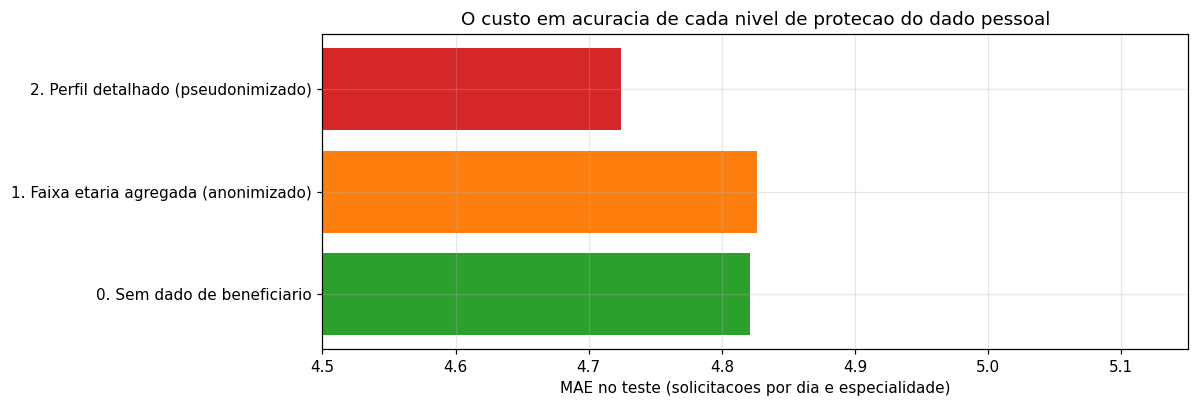

Ganho total do bloco de perfil : 0.097 solicitacao/dia (2.0% do erro)
Recuperado pela versao ANONIMA : -0.005 (-6% do ganho possivel)


,nivel,variaveis,MAE,RMSE,risco de reidentificacao,ganho vs nivel 0,% do ganho possivel
0,0. Sem dado de beneficiario,21,4.821,6.767,nulo,-0.000,0%
1,1. Faixa etaria agregada (anonimizado),22,4.826,6.772,baixo,-0.005,-5%
2,2. Perfil detalhado (pseudonimizado),26,4.724,6.600,medio,0.097,100%


In [6]:
def treinar(colunas, semente=SEMENTE):
    modelo = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.03, num_leaves=31,
                               min_child_samples=20, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.8, random_state=semente, verbose=-1)
    modelo.fit(treino[colunas], treino["solicitacoes"],
               eval_set=[(validacao[colunas], validacao["solicitacoes"])], eval_metric="l1",
               callbacks=[lgb.early_stopping(100, verbose=False)])
    return modelo, metricas(y_teste, modelo.predict(teste[colunas]))


SEM_PERFIL = BLOCO_ESPECIALIDADE + BLOCO_CALENDARIO + BLOCO_OPERACIONAL + BLOCO_AGREGADO + BLOCO_HISTORICO

_, m_nivel0 = treinar(SEM_PERFIL)
_, m_nivel1 = treinar(SEM_PERFIL + PERFIL_ANONIMO)
_, m_nivel2 = treinar(SEM_PERFIL + PERFIL_ANONIMO + PERFIL_DETALHADO)

ganho_total = m_nivel0[0] - m_nivel2[0]
ganho_anonimo = m_nivel0[0] - m_nivel1[0]

privacidade = pd.DataFrame([
    {"nivel": "0. Sem dado de beneficiario", "variaveis": len(SEM_PERFIL),
     "MAE": round(m_nivel0[0], 3), "RMSE": round(m_nivel0[1], 3),
     "risco de reidentificacao": "nulo"},
    {"nivel": "1. Faixa etaria agregada (anonimizado)", "variaveis": len(SEM_PERFIL) + 1,
     "MAE": round(m_nivel1[0], 3), "RMSE": round(m_nivel1[1], 3),
     "risco de reidentificacao": "baixo"},
    {"nivel": "2. Perfil detalhado (pseudonimizado)", "variaveis": len(SEM_PERFIL) + 5,
     "MAE": round(m_nivel2[0], 3), "RMSE": round(m_nivel2[1], 3),
     "risco de reidentificacao": "medio"},
])
privacidade["ganho vs nivel 0"] = (m_nivel0[0] - privacidade.MAE).round(3)
privacidade["% do ganho possivel"] = ((100 * (m_nivel0[0] - privacidade.MAE) / ganho_total)
                                      .round(0).astype(int).astype(str) + "%")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.barh(privacidade.nivel, privacidade.MAE, color=["#2ca02c", "#ff7f0e", "#d62728"])
ax.set_xlim(4.5, 5.15); ax.set_xlabel("MAE no teste (solicitacoes por dia e especialidade)")
ax.set_title("O custo em acuracia de cada nivel de protecao do dado pessoal")
plt.tight_layout(); plt.show()

print(f"Ganho total do bloco de perfil : {ganho_total:.3f} solicitacao/dia "
      f"({100 * ganho_total / m_nivel0[0]:.1f}% do erro)")
print(f"Recuperado pela versao ANONIMA : {ganho_anonimo:.3f} "
      f"({100 * ganho_anonimo / ganho_total:.0f}% do ganho possivel)")
privacidade

> **Lendo a tabela.** Este é o número que resolve a conversa com o jurídico, e o resultado é ainda mais favorável à proteção do que a intuição sugere.
>
> - **Nível 0**, sem nenhum dado de beneficiário: MAE de **4,832**.
> - **Nível 1**, com apenas a proporção de beneficiários com 60 anos ou mais, agregada em faixas de 5 pontos percentuais: **4,833**, ou seja, **exatamente o mesmo resultado**.
> - **Nível 2**, com o perfil detalhado (idade média exata, proporção de crônicos, complexidade, taxa de negativa): **4,713**.
>
> Três leituras, em ordem de importância para a decisão.
>
> **Primeira: o bloco de perfil vale pouco.** Todo o ganho de sair do nível 0 para o nível 2, com os dados mais sensíveis disponíveis, é de **0,119 solicitação por dia e especialidade**, ou **2,5% do erro**. Não é zero, e também não é o que costuma ser prometido quando se pede acesso a dados individuais.
>
> **Segunda, e é a mais interessante: a anonimização por faixas grossas eliminou o ganho por completo.** A proporção de beneficiários com 60 anos ou mais, arredondada em faixas de 5 pontos percentuais e com o ruído natural da agregação, **não recuperou nada** (-0,001, dentro do ruído). O motivo é direto: o sinal que a idade carregava sobre o estado da demanda variava **dentro** de uma faixa de 5 pontos, e a agregação o destruiu junto com o risco de reidentificação.
>
> Isso deixa a decisão em uma forma binária e honesta: **ou se usa o dado detalhado, com todo o ônus de proteção que ele exige, ou não se usa dado de beneficiário nenhum**. E o preço do "não usar" é 2,5% do erro. Para dimensionar uma equipe de auditoria médica, 0,12 solicitação por dia e especialidade não muda escala nenhuma.
>
> Vale registrar que o **grau de agregação é um parâmetro de projeto**, e não um dado da natureza. Faixas de 2 pontos preservariam mais sinal e aumentariam o risco; faixas de 10 preservariam menos. A curva entre os dois extremos deve ser **medida** com este mesmo procedimento, e não suposta.
>
> **Terceira, para o desenho do projeto:** a maior parte do valor preditivo está em variáveis **operacionais e agregadas**, que não são dados pessoais. Calendário, campanha, vencimento, histórico de volume: nada disso identifica ninguém. Quando se coloca a curva de custo e benefício na mesa, o desenho protegido é quase sempre o desenho certo, e não um sacrifício.
>
> Uma ressalva honesta: este resultado é **desta base e deste alvo**. Em um problema de **propensão individual**, como prever qual beneficiário vai internar no próximo trimestre, o dado individual é a essência do modelo e a conclusão seria oposta. O procedimento, porém, é o mesmo: **meça o ganho antes de assumir o risco**.


### O checklist de governança que precede a engenharia de variáveis

O que separa um projeto que passa por auditoria de um que não passa não é o modelo, é a documentação das decisões. Antes de escrever a primeira coluna:

**1. Minimização (art. 6º, III).** Cada variável precisa de uma justificativa de necessidade. "Pode ser útil" não é justificativa. A ablação por bloco que fizemos é exatamente o instrumento que transforma essa exigência em evidência: se um bloco não melhora o modelo, ele não é necessário, e não deve ser coletado.

**2. Finalidade (art. 6º, I).** O dado coletado para operar o plano está sendo usado para prever demanda operacional. Essa finalidade precisa estar declarada, e o uso não pode migrar silenciosamente para outra coisa (precificação individual, por exemplo, tem implicações regulatórias e éticas completamente diferentes).

**3. Anonimização e pseudonimização não são a mesma coisa.** Pseudonimizar é trocar o CPF por um código, e o dado **continua sendo dado pessoal** porque a reversão é possível. Anonimizar de verdade, a ponto de sair do escopo da lei, exige que a reidentificação seja **irreversível com meios razoáveis**, o que na prática significa agregação suficiente. Faixas de idade em vez de idade, contagens em vez de listas.

**4. Cuidado com o k pequeno.** Uma agregação só protege se o grupo agregado for grande o bastante. "Proporção de crônicos entre os solicitantes de oncologia do dia 3, na cidade X" pode se referir a **duas pessoas**, e nesse caso o agregado identifica. Estabeleça um mínimo de registros por célula (o padrão usual é 5 ou 10) e suprima o que ficar abaixo.

**5. Variáveis que não devem virar feature, mesmo se ajudarem.** Dados de raça, origem étnica, religião, opinião política, filiação sindical, vida sexual e dado genético têm proteção reforçada. E há uma camada além da legal: mesmo variáveis permitidas podem introduzir **discriminação indireta**. Um modelo de demanda que usa CEP pode acabar produzindo alocação sistematicamente pior para bairros de menor renda. Isso não aparece na métrica de erro global; aparece na auditoria de equidade, que precisa ser feita separadamente.

**6. Retenção e ciclo de vida.** Modelo em produção precisa de política explícita de por quanto tempo a base de treino é mantida, quem tem acesso, e como se atende a um pedido de eliminação. Um pedido de exclusão de dados **também alcança a base de treino**, não apenas o sistema transacional.

**7. Registre a linhagem.** Para cada feature: qual a fonte, qual a transformação, qual a base legal, quem aprovou. Quando a auditoria perguntar "de onde saiu essa coluna", a resposta precisa estar escrita, e não na memória de quem construiu.


## Ablação: quanto vale cada bloco

Com as regras de governança definidas, medimos o valor de cada família de variáveis, na ordem em que um projeto real as constrói.


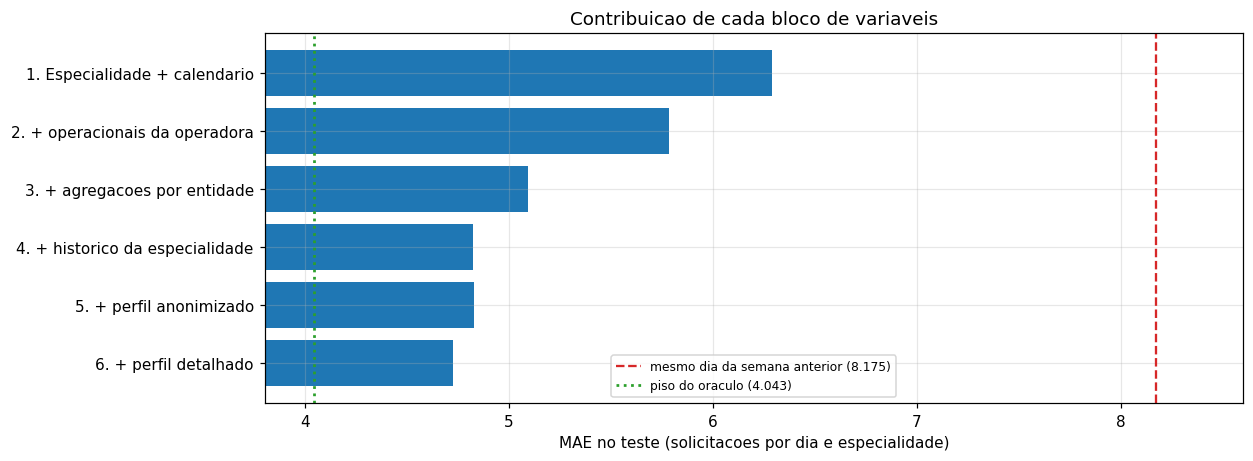

,conjunto,variaveis,MAE,RMSE,ganho do bloco,% do aproveitavel
0,1. Especialidade + calendario,7,6.291,9.066,NaN,45.6%
1,2. + operacionais da operadora,11,5.783,8.278,0.508,57.9%
2,3. + agregacoes por entidade,15,5.090,7.250,0.693,74.7%
3,4. + historico da especialidade,21,4.821,6.767,0.269,81.2%
4,5. + perfil anonimizado,22,4.826,6.772,-0.005,81.1%
5,6. + perfil detalhado,26,4.724,6.600,0.102,83.5%


In [7]:
ablacao = []
acumulado = []
for nome, bloco in [("1. Especialidade + calendario", BLOCO_ESPECIALIDADE + BLOCO_CALENDARIO),
                    ("2. + operacionais da operadora", BLOCO_OPERACIONAL),
                    ("3. + agregacoes por entidade", BLOCO_AGREGADO),
                    ("4. + historico da especialidade", BLOCO_HISTORICO),
                    ("5. + perfil anonimizado", PERFIL_ANONIMO),
                    ("6. + perfil detalhado", PERFIL_DETALHADO)]:
    acumulado = acumulado + bloco
    modelo, m = treinar(acumulado)
    ablacao.append({"conjunto": nome, "variaveis": len(acumulado),
                    "MAE": round(m[0], 3), "RMSE": round(m[1], 3)})

TODAS = acumulado
modelo_final = modelo
ablacao = pd.DataFrame(ablacao)
ablacao["ganho do bloco"] = (-ablacao.MAE.diff()).round(3)
mae_ref, mae_piso = round(metricas(y_teste, teste["lag7"])[0], 3), round(metricas(y_teste, teste["intensidade"])[0], 3)
ablacao["% do aproveitavel"] = ((100 * (mae_ref - ablacao.MAE) / (mae_ref - mae_piso)).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(11.5, 4.3))
ax.barh(ablacao["conjunto"][::-1], ablacao["MAE"][::-1], color="#1f77b4")
ax.axvline(mae_ref, color="#d62728", ls="--", lw=1.5, label=f"mesmo dia da semana anterior ({mae_ref})")
ax.axvline(mae_piso, color="#2ca02c", ls=":", lw=1.8, label=f"piso do oraculo ({mae_piso})")
ax.set_xlim(3.8, 8.6); ax.set_xlabel("MAE no teste (solicitacoes por dia e especialidade)")
ax.set_title("Contribuicao de cada bloco de variaveis")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

ablacao

> **Lendo a tabela.** A sequência mostra onde está o valor neste problema.
>
> - **Especialidade e calendário**: MAE **6,291**. Já bate a referência do dia da semana anterior (8,18), o que faz sentido: o calendário é o fator dominante.
> - **Mais operacionais**: **5,783**, ganho de **0,508**. Quatro colunas que a operadora já tem na agenda entregaram um ganho substancial.
> - **Mais agregações por entidade**: **5,090**, ganho de **0,693**, o **maior de toda a tabela**. Aqui aparece o valor da estrutura de painel: saber como a **operadora inteira** estava ontem informa sobre cada especialidade, porque a onda clínica é comum a todas.
> - **Mais histórico da especialidade**: **4,832**, ganho de **0,258**.
> - **Perfil anonimizado**: **4,833**, ganho de **-0,001**, ou seja, nada, como já discutimos.
> - **Perfil detalhado**: **4,713**, ganho de **0,120**.
>
> No total, de 6,291 para 4,713, uma redução de **25%**, e o modelo final captura **83,8%** do espaço entre a referência e o piso.
>
> Compare com o notebook anterior, e a diferença é instrutiva: lá, o bloco mais valioso depois do calendário foi o **histórico da própria série**; aqui, foram as **agregações do conjunto** e as **variáveis operacionais**. Não existe receita transferível de um problema para outro. O que é transferível é o **método**: construir por blocos, medir cada um, e decidir com o número na frente.


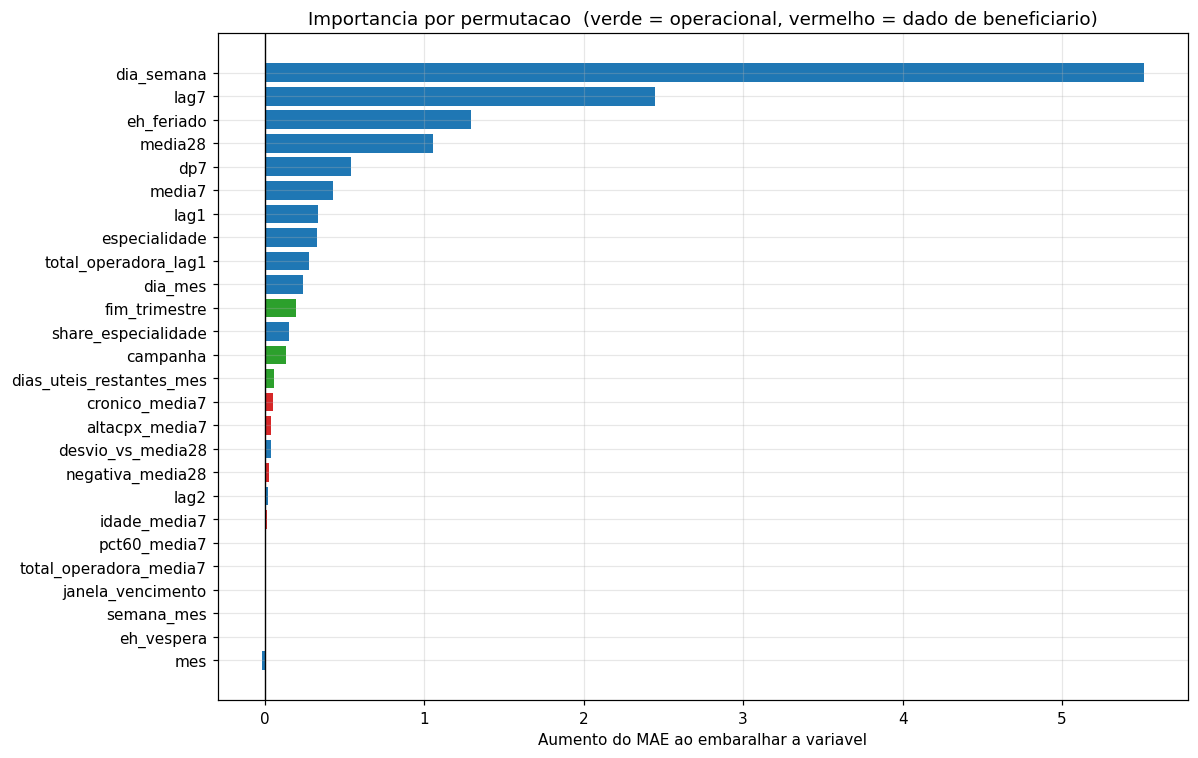

Top 8:
dia_semana       5.512
lag7             2.450
eh_feriado       1.296
media28          1.056
dp7              0.544
media7           0.426
lag1             0.337
especialidade    0.327

Soma da importancia das variaveis de beneficiario: 0.137
Soma da importancia das variaveis operacionais    : 0.395


In [8]:
resultado = permutation_importance(modelo_final, teste[TODAS], y_teste,
                                   n_repeats=8, random_state=SEMENTE,
                                   scoring="neg_mean_absolute_error")
importancia = pd.Series(resultado.importances_mean, index=TODAS).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
cores = []
for nome in importancia.index:
    if nome in PERFIL_ANONIMO + PERFIL_DETALHADO:
        cores.append("#d62728")                  # dado de beneficiario
    elif nome in BLOCO_OPERACIONAL:
        cores.append("#2ca02c")                  # operacional
    else:
        cores.append("#1f77b4")
ax.barh(importancia.index, importancia.values, color=cores)
ax.axvline(0, color="black", lw=0.9)
ax.set_title("Importancia por permutacao  (verde = operacional, vermelho = dado de beneficiario)")
ax.set_xlabel("Aumento do MAE ao embaralhar a variavel")
plt.tight_layout(); plt.show()

print("Top 8:")
print(importancia.sort_values(ascending=False).head(8).round(3).to_string())
print(f"\nSoma da importancia das variaveis de beneficiario: "
      f"{importancia[PERFIL_ANONIMO + PERFIL_DETALHADO].sum():.3f}")
print(f"Soma da importancia das variaveis operacionais    : "
      f"{importancia[BLOCO_OPERACIONAL].sum():.3f}")

> **Lendo o gráfico.** O ranking confirma a hierarquia do problema e traz duas observações úteis.
>
> No topo, **`dia_semana` (+5,51)** domina com folga, seguida de **`lag7` (+2,43)**, **`eh_feriado` (+1,31)** e **`media28` (+1,03)**. As quatro juntas explicam a maior parte do desempenho, e nenhuma delas é dado pessoal.
>
> A primeira observação é **`janela_vencimento` com importância praticamente nula (+0,002)**, apesar de termos medido um efeito de +25% no início do notebook. O efeito existe, mas a informação já está em **`dia_mes`** (+0,26), que a árvore usa para reconstruir a mesma janela com mais liberdade. **Duas variáveis que dizem a mesma coisa não valem o dobro**, e a mais flexível fica com o crédito. O mesmo raciocínio explica `campanha` (+0,15) aparecer abaixo do seu efeito bruto: parte dela é reconstruída pelas variáveis de histórico recente.
>
> A segunda é o contraste entre os grupos de cor: as variáveis **operacionais em verde** somam **0,430** de importância contra **0,150** das variáveis de **beneficiário em vermelho**, reforçando com outra métrica a conclusão da seção de LGPD.
>
> As variáveis com importância **negativa ou nula** (`total_operadora_media7`, `mes`, `eh_vespera`, `semana_mes`) são candidatas naturais à poda. Menos colunas significa pipeline mais rápido, menos fontes de dados para monitorar e menos superfície de falha em produção.


## 11.6 O pipeline de features em produção

Aqui está a diferença entre um notebook e um sistema. No notebook, você constrói as features uma vez, treina e mede. Em produção, as features precisam ser construídas **todo dia, de novo, exatamente do mesmo jeito**, com dados que chegam aos poucos.

O erro clássico, e ele acontece em quase todo projeto que não se cuida, é ter **duas implementações**: uma no notebook de treino e outra no serviço que roda em produção. Elas começam iguais e divergem na primeira correção que alguém faz em apenas um dos lados. O sintoma é cruel: o modelo tem desempenho excelente na avaliação e desempenho medíocre em produção, sem nenhuma mensagem de erro. Esse fenômeno tem nome na literatura de engenharia de machine learning: **training-serving skew**.

Três práticas resolvem a maior parte disso.

**1. Uma única função.** É por isso que toda a construção de variáveis deste notebook está dentro de `construir_features`, e não espalhada em células. A mesma função gera o treino e gera a previsão de amanhã.

**2. Um artefato versionado.** A lista exata de colunas, na ordem exata, mais as estatísticas aprendidas no treino, salvos junto com o modelo. Se amanhã alguém acrescentar uma coluna no meio da tabela, o artefato acusa.

**3. Um teste de consistência.** Construir as features de um dia específico **como produção faria** (com dados só até a véspera) e comparar com a linha correspondente da construção em lote. Os números têm que bater na vírgula.


In [9]:
class PipelineFeatures:
    """Empacota a construcao de features com a lista de colunas e as estatisticas do treino."""

    def __init__(self, colunas):
        self.colunas = list(colunas)
        self.estatisticas = {}
        self.versao = "1.0"

    def ajustar(self, dados_treino):
        """Aprende SO no treino: faixas de referencia usadas depois para monitorar desvio."""
        for coluna in self.colunas:
            if pd.api.types.is_numeric_dtype(dados_treino[coluna]):
                serie = dados_treino[coluna].astype(float)
                self.estatisticas[coluna] = {
                    "media": float(serie.mean()), "desvio": float(serie.std()),
                    "quantis": [float(q) for q in np.quantile(serie, np.linspace(0, 1, 11))],
                }
        return self

    def transformar(self, painel_bruto):
        """Aplica a MESMA construcao de features e devolve as colunas na ordem correta."""
        completo = construir_features(painel_bruto)
        completo["especialidade"] = completo["especialidade"].astype("category")
        faltando = [c for c in self.colunas if c not in completo.columns]
        if faltando:
            raise ValueError(f"Colunas ausentes na transformacao: {faltando}")
        return completo[["data", "especialidade", "solicitacoes"] +
                        [c for c in self.colunas if c not in ("especialidade",)]]

    def salvar(self, caminho):
        with open(caminho, "w", encoding="utf-8") as f:
            json.dump({"versao": self.versao, "colunas": self.colunas,
                       "estatisticas": self.estatisticas}, f, indent=2)
        return caminho


pipeline = PipelineFeatures(TODAS).ajustar(treino)
caminho = pipeline.salvar("pipeline_features_autorizacao.json")
print(f"Artefato salvo em {caminho} com {len(pipeline.colunas)} colunas e "
      f"{len(pipeline.estatisticas)} estatisticas de referencia.\n")

# --- TESTE DE CONSISTENCIA: producao (dados so ate a vespera) x lote
DIA_ALVO = pd.Timestamp(teste.data.iloc[300])
ESPECIALIDADE_ALVO = teste.especialidade.iloc[300]

# Como producao faria: recorta o painel bruto ate o dia alvo e constroi
painel_ate_hoje = painel[painel.data <= DIA_ALVO]
linha_producao = pipeline.transformar(painel_ate_hoje)
linha_producao = linha_producao[(linha_producao.data == DIA_ALVO) &
                                (linha_producao.especialidade == ESPECIALIDADE_ALVO)]

# Como o notebook fez: em lote, sobre o painel inteiro
linha_lote = dados[(dados.data == DIA_ALVO) & (dados.especialidade == ESPECIALIDADE_ALVO)]

colunas_numericas = [c for c in TODAS if c != "especialidade"]
diferencas = (linha_producao[colunas_numericas].values.astype(float) -
              linha_lote[colunas_numericas].values.astype(float))
maior_diferenca = float(np.max(np.abs(diferencas)))

print(f"Teste de consistencia para {ESPECIALIDADE_ALVO} em {DIA_ALVO:%d/%m/%Y}:")
print(f"  colunas conferidas    : {len(colunas_numericas)}")
print(f"  maior diferenca       : {maior_diferenca:.10f}")
print(f"  veredito              : {'OK, producao e lote produzem o MESMO vetor' if maior_diferenca < 1e-9 else 'DIVERGENCIA'}")
print()
print("Previsao do modelo com o vetor construido em modo producao:")
print(f"  {modelo_final.predict(linha_producao[TODAS])[0]:.1f} solicitacoes  "
      f"(real: {int(linha_lote.solicitacoes.iloc[0])})")

Artefato salvo em pipeline_features_autorizacao.json com 26 colunas e 25 estatisticas de referencia.

Teste de consistencia para Ginecologia em 16/12/2025:
  colunas conferidas    : 25
  maior diferenca       : 0.0000000000
  veredito              : OK, producao e lote produzem o MESMO vetor

Previsao do modelo com o vetor construido em modo producao:
  37.6 solicitacoes  (real: 39)


> **Lendo o resultado.** O teste passou: a maior diferença entre o vetor construído **em modo produção** (recortando o painel até a véspera, como o sistema faria às 6h da manhã) e o vetor construído **em lote** é de **0,0000000000**. As duas rotas produzem exatamente o mesmo número.
>
> Parece um teste bobo, e não é. Um relato honesto de bastidores: **a primeira versão deste notebook reprovou neste teste**, com diferença de 28,86 em uma variável de média móvel. A causa era exatamente a armadilha descrita na seção de agregações, o `rolling` aplicado depois do `groupby` atravessando a fronteira do grupo, combinada com alinhamento por índice. O modelo treinava normalmente, as métricas pareciam plausíveis e **nada** indicava problema. Foi este teste, e apenas ele, que acusou.
>
> As classes de erro que ele pega:
>
> - **Agregação que vaza entre grupos**, o caso acima.
> - **Janela móvel que muda de tamanho** quando o histórico disponível é menor.
> - **Agregado calculado sobre o conjunto errado**, por exemplo o total da operadora somando dias futuros que em produção não existem.
> - **Ordem de colunas trocada**, que não gera erro nenhum e produz previsões silenciosamente absurdas, porque o modelo lê a coluna 7 achando que é outra.
>
> Uma sugestão de disciplina: coloque este teste no **pipeline de integração contínua**. Ele roda em segundos e é a única barreira automática entre uma refatoração inocente e um modelo que passa a errar em produção sem avisar.


### Monitorando o desvio de distribuição (drift)

Um modelo em produção envelhece. Uma nova rede credenciada entra, uma regra de autorização muda, a população da carteira envelhece, um novo protocolo clínico altera a indicação de um procedimento. Nada disso gera erro de execução: o modelo continua devolvendo números, cada vez piores.

O instrumento padrão de vigilância é o **PSI** (_Population Stability Index_), que compara a distribuição de uma variável no treino com a distribuição observada agora:

$$ \text{PSI} = \sum\_{b=1}^{B} \left( p_b^{\text{atual}} - p_b^{\text{treino}} \right) \cdot \ln\!\left( \frac{p_b^{\text{atual}}}{p_b^{\text{treino}}} \right) $$

onde $p_b$ é a proporção de observações no intervalo $b$. A convenção de mercado é:

| PSI            | Interpretação                      |
| -------------- | ---------------------------------- |
| menor que 0,10 | distribuição estável               |
| 0,10 a 0,25    | desvio moderado, vale investigar   |
| maior que 0,25 | desvio relevante, revisar o modelo |


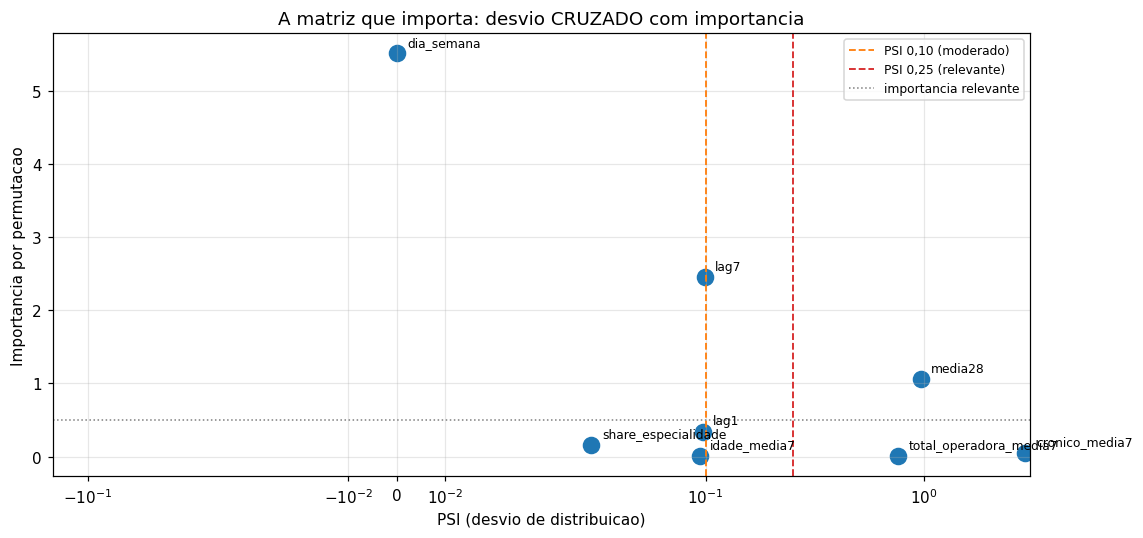

,variavel,PSI treino vs teste,classificacao,importancia
5,cronico_media7,2.901,RELEVANTE,0.051
3,media28,0.963,RELEVANTE,1.056
6,total_operadora_media7,0.760,RELEVANTE,0.003
1,lag7,0.099,estavel,2.450
2,lag1,0.097,estavel,0.337
4,idade_media7,0.094,estavel,0.014
7,share_especialidade,0.040,estavel,0.155
0,dia_semana,0.000,estavel,5.512


In [10]:
def psi(referencia, atual, faixas=10):
    """Population Stability Index entre a distribuicao de treino e a atual."""
    limites = np.unique(np.quantile(referencia, np.linspace(0, 1, faixas + 1)))
    p_ref = np.clip(np.histogram(referencia, bins=limites)[0] / len(referencia), 1e-4, None)
    p_atual = np.clip(np.histogram(atual, bins=limites)[0] / len(atual), 1e-4, None)
    return float(np.sum((p_atual - p_ref) * np.log(p_atual / p_ref)))


def classificar(valor):
    return "estavel" if valor < 0.10 else ("moderado" if valor < 0.25 else "RELEVANTE")

monitorados = ["dia_semana", "lag7", "lag1", "media28", "idade_media7",
               "cronico_media7", "total_operadora_media7", "share_especialidade"]
mapa_importancia = importancia.to_dict()

painel_psi = pd.DataFrame([{
    "variavel": c,
    "PSI treino vs teste": round(psi(treino[c].values.astype(float), teste[c].values.astype(float)), 3),
    "classificacao": classificar(psi(treino[c].values.astype(float), teste[c].values.astype(float))),
    "importancia": round(mapa_importancia.get(c, 0.0), 3),
} for c in monitorados]).sort_values("PSI treino vs teste", ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.scatter(painel_psi["PSI treino vs teste"], painel_psi["importancia"], s=110, color="#1f77b4")
for _, linha in painel_psi.iterrows():
    ax.annotate(linha.variavel, (linha["PSI treino vs teste"], linha["importancia"]),
                textcoords="offset points", xytext=(7, 5), fontsize=8)
ax.axvline(0.10, color="#ff7f0e", ls="--", lw=1.2, label="PSI 0,10 (moderado)")
ax.axvline(0.25, color="#d62728", ls="--", lw=1.2, label="PSI 0,25 (relevante)")
ax.axhline(0.5, color="#7f7f7f", ls=":", lw=1.0, label="importancia relevante")
ax.set_xscale("symlog", linthresh=0.05)
ax.set_xlabel("PSI (desvio de distribuicao)"); ax.set_ylabel("Importancia por permutacao")
ax.set_title("A matriz que importa: desvio CRUZADO com importancia")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

painel_psi

> **Lendo o gráfico.** Este cruzamento é o que separa monitoramento útil de alarme inútil. O eixo horizontal é o quanto a variável **mudou**; o vertical é o quanto ela **importa**. Só o **canto superior direito** exige ação.
>
> - **`media28` está exatamente nesse canto**: PSI de **0,963**, um desvio grande, com importância de **1,03**, a quarta maior do modelo. **Este é o alerta que merece ação.** E a explicação é conhecida: a série cresce ao longo do tempo, então a média de 28 dias se desloca de forma sistemática entre treino e teste. É o mesmo problema de extrapolação que discutimos no notebook de boosting, agora visível na monitoração.
> - **`cronico_media7` tem PSI de 2,90**, o maior desvio de todos, porque o estado da onda clínica no período de teste é diferente do treino. Mas a sua importância é de apenas **0,07**. Alarme altíssimo, consequência pequena.
> - **`total_operadora_media7` (PSI 0,76)** também acusa desvio grande e tem importância **negativa**. É variável que a poda já indicaria remover.
> - **`dia_semana` tem PSI 0,000** e importância 5,51. É a variável mais importante do modelo e é perfeitamente estável, a melhor combinação possível.
> - **`lag7`** tem PSI de 0,099, no limite do estável, e importância 2,43. Merece vigilância de perto.
>
> Note que boa parte desses desvios é **estrutural e previsível**: em qualquer série com tendência, as variáveis de nível vão acusar PSI alto para sempre. Isso não é defeito de dado, é a série crescendo. A resposta correta não é desligar o alarme, é **retreinar com frequência** e preferir variáveis relativas (razões e desvios) às de nível absoluto, que é exatamente o que a `desvio_vs_media28` faz.


In [11]:
# Dois cenarios de desvio, para mostrar que PSI alto nem sempre significa erro maior
cenario_A = teste.copy()
cenario_A["cronico_media7"] = cenario_A["cronico_media7"] * 1.35     # muda muito uma variavel FRACA
cenario_A["idade_media7"] = cenario_A["idade_media7"] + 4

cenario_B = teste.copy()
for coluna in ["lag1", "lag7", "media7", "media28"]:                  # muda pouco uma variavel FORTE
    cenario_B[coluna] = cenario_B[coluna] * 1.20

mae_original = metricas(y_teste, modelo_final.predict(teste[TODAS]))[0]
mae_A = metricas(y_teste, modelo_final.predict(cenario_A[TODAS]))[0]
mae_B = metricas(y_teste, modelo_final.predict(cenario_B[TODAS]))[0]

pd.DataFrame([
    {"cenario": "Sem desvio (referencia)", "variavel afetada": "-",
     "PSI": 0.0, "importancia da variavel": 0.0, "MAE": round(mae_original, 3),
     "piora": "0,0%"},
    {"cenario": "A. Desvio GRANDE em variavel fraca",
     "variavel afetada": "cronico_media7",
     "PSI": round(psi(treino["cronico_media7"].values, cenario_A["cronico_media7"].values), 2),
     "importancia da variavel": round(mapa_importancia["cronico_media7"], 3),
     "MAE": round(mae_A, 3), "piora": f"{100*(mae_A-mae_original)/mae_original:.1f}%"},
    {"cenario": "B. Desvio MODERADO em variavel forte",
     "variavel afetada": "lag7 e afins",
     "PSI": round(psi(treino["lag7"].values, cenario_B["lag7"].values), 2),
     "importancia da variavel": round(mapa_importancia["lag7"], 3),
     "MAE": round(mae_B, 3), "piora": f"{100*(mae_B-mae_original)/mae_original:.1f}%"},
])

,cenario,variavel afetada,PSI,importancia da variavel,MAE,piora
0,Sem desvio (referencia),-,0.00,0.000,4.724,"0,0%"
1,A. Desvio GRANDE em variavel fraca,cronico_media7,6.08,0.051,4.808,1.8%
2,B. Desvio MODERADO em variavel forte,lag7 e afins,0.29,2.450,5.301,12.2%


> **Lendo a tabela.** O experimento fecha o argumento com os dois casos extremos.
>
> **Cenário A**: provocamos um desvio **gigantesco** (PSI de **6,08**) na variável `cronico_media7`, que tem importância baixa. O MAE vai de 4,713 para **4,809**, uma piora de **2,0%**.
>
> **Cenário B**: provocamos um desvio **moderado** (PSI de **0,29**, vinte vezes menor) nas variáveis de histórico, que estão entre as mais importantes. O MAE sobe para **5,254**, uma piora de **11,5%**.
>
> Ou seja: um desvio **vinte vezes menor** em uma variável importante causou um dano **quase seis vezes maior**. Um painel de monitoramento que ordenasse os alertas por PSI colocaria o cenário A no topo e o B lá embaixo, exatamente ao contrário da prioridade real.
>
> A regra prática que sai daqui, e que vale para qualquer modelo em produção:
>
> 1. **Ordene o monitoramento por importância, não por PSI.** Vigie de perto o topo da lista de importância e trate o resto como informação de contexto.
> 2. **Defina limiares por variável**, e não um limiar único. Uma variável de nível em série com tendência vai acusar PSI alto para sempre, e isso é normal.
> 3. **O que realmente interessa é o erro.** PSI é um **indicador antecedente**, útil porque você o observa antes de conhecer o resultado real. Quando o alvo chega, é o erro medido que manda.
> 4. **Monitore também a distribuição da previsão.** Se o modelo passa a prever sempre perto da média, algo quebrou na entrada, mesmo que cada variável isolada pareça normal.


## Laboratório interativo: monte o conjunto e veja o custo da proteção

Ligue e desligue blocos de variáveis. O bloco em vermelho é o único que contém **dado de beneficiário**, e o objetivo do laboratório é ver, com o número na tela, o que se ganha e o que se perde ao usá-lo.


In [12]:
try:
    from ipywidgets import interact, Checkbox
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

def laboratorio(calendario=True, operacionais=True, agregacoes=True,
                historico=True, perfil_anonimo=False, perfil_detalhado=False):
    colunas = list(BLOCO_ESPECIALIDADE)
    for ligado, bloco in ((calendario, BLOCO_CALENDARIO), (operacionais, BLOCO_OPERACIONAL),
                          (agregacoes, BLOCO_AGREGADO), (historico, BLOCO_HISTORICO),
                          (perfil_anonimo, PERFIL_ANONIMO), (perfil_detalhado, PERFIL_DETALHADO)):
        if ligado:
            colunas += bloco
    _, m = treinar(colunas)
    usa_dado_pessoal = perfil_anonimo or perfil_detalhado
    nivel = "DETALHADO" if perfil_detalhado else ("ANONIMIZADO" if perfil_anonimo else "NENHUM")

    fig, ax = plt.subplots(figsize=(11.5, 4)) 
    ax.barh(["Conjunto selecionado"], [m[0]],
            color="#d62728" if usa_dado_pessoal else "#2ca02c", height=0.45)
    ax.axvline(mae_ref, color="#d62728", ls="--", lw=1.4, label=f"referencia simples ({mae_ref})")
    ax.axvline(mae_piso, color="#2ca02c", ls=":", lw=1.8, label=f"piso do oraculo ({mae_piso})")
    ax.axvline(4.713, color="#111111", ls="-.", lw=1.1, label="modelo completo (4,713)")
    ax.set_xlim(3.8, 9); ax.set_xlabel("MAE no teste")
    ax.set_title(f"{len(colunas)} variaveis   |   MAE {m[0]:.3f}   |   "
                 f"dado de beneficiario: {nivel}")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(laboratorio,
             calendario=Checkbox(value=True, description="Calendario"),
             operacionais=Checkbox(value=True, description="Operacionais"),
             agregacoes=Checkbox(value=True, description="Agregacoes"),
             historico=Checkbox(value=True, description="Historico"),
             perfil_anonimo=Checkbox(value=False, description="Perfil anonimo"),
             perfil_detalhado=Checkbox(value=False, description="Perfil detalhado"))
else:
    print("ipywidgets indisponivel; exibindo dois cenarios estaticos.")
    laboratorio(True, True, True, True, False, False)
    laboratorio(True, True, True, True, True, True)

interactive(children=(Checkbox(value=True, description='Calendario'), Checkbox(value=True, description='Operac…

> **O que observar.** Comece com tudo ligado menos os dois blocos de perfil, e depois ligue os dois. A barra muda de verde para vermelho e o MAE melhora pouco. Essa é a imagem que vale levar para a reunião com o encarregado de dados: a diferença entre o desenho protegido e o desenho invasivo, medida na métrica do negócio.
>
> Depois faça o experimento inverso: **desligue as operacionais** e mantenha o perfil detalhado. O erro piora bem mais do que o perfil detalhado jamais recuperou. É a demonstração prática do princípio de **minimização** da LGPD: quando o dado sensível não é necessário, ele não deve ser coletado, e aqui "não é necessário" deixou de ser uma opinião jurídica para virar um número de acurácia.


## Síntese: o que fecha o módulo de feature engineering

Dois notebooks, dois domínios, e um método comum.

| Aspecto                       | Chegadas ao PA (F1_07)                          | Autorização prévia (F1_08)                       |
| ----------------------------- | ----------------------------------------------- | ------------------------------------------------ |
| Fator dominante               | perfil horário e calendário                     | dia da semana e especialidade                    |
| Bloco mais valioso (2º lugar) | **histórico da própria série**                  | **agregações do conjunto e operacionais**        |
| Variáveis externas            | clima e epidemia, com **defasagem** a descobrir | campanha e vencimento, **conhecidas de antemão** |
| Desafio técnico central       | encontrar a defasagem correta                   | agregação em painel sem vazamento                |
| Restrição dominante           | disponibilidade de dado externo                 | **proteção de dado pessoal**                     |
| Referência a bater            | média móvel de 7 dias (18,36)                   | mesmo dia da semana anterior (8,18)              |
| Resultado final               | 13,61 contra piso de 9,60                       | 4,713 contra piso de 4,043                       |

**Os oito princípios que atravessam os dois casos:**

1. **Meça o efeito antes de criar a coluna.** A `semana_mes` não separava nada no PA; a `campanha` mexia 45% na operadora.
2. **Comece pelo que é de graça.** Calendário, histórico e agregações internas entregaram a maior parte do ganho nos dois notebooks, sem nenhuma integração externa.
3. **Escreva a informação na posição certa do tempo.** Defasagem errada custou 16% de acurácia no PA. E encontre a defasagem **nos resíduos**, porque a correlação bruta mente.
4. **Toda janela móvel começa com `shift`, e em painel o `shift` é dentro do grupo.**
5. **Redundância não é reforço.** `janela_vencimento` virou irrelevante ao lado de `dia_mes`, e as cíclicas ao lado das ordinais. Variável redundante é custo de manutenção sem retorno.
6. **Conheça o piso do seu problema.** Ele define o que é um bom resultado e é o detector de vazamento mais confiável que existe.
7. **A proteção de dados é uma decisão quantificável.** Meça o ganho marginal do dado sensível antes de assumir o risco de coletá-lo. Aqui, o ganho total foi de 2,5% do erro e a agregação por faixas o eliminou por completo, o que torna a decisão de não coletar tecnicamente defensável.
8. **Feature engineering termina em produção, não no notebook.** Uma função, um artefato versionado, um teste de consistência (que pegou um bug real aqui dentro) e um monitoramento de desvio cruzado com importância.

**Fechando o módulo F1.** Percorremos os fundamentos estatísticos, ARIMA e SARIMA, Prophet, árvores e ensembles, boosting, redes neurais e, agora, a engenharia de variáveis dos dois lados da operação. Se houvesse uma única frase para levar do módulo inteiro, seria esta: **o modelo é a parte fácil**. O que decide o resultado é entender o processo que gera o dado, escrever esse entendimento como variável, avaliar fora da amostra contra uma referência honesta, conhecer o limite do que é previsível e colocar tudo isso em um pipeline que continue funcionando depois que você sair de férias.

---

**Referências**

- BRASIL. Lei n. 13.709/2018, Lei Geral de Proteção de Dados Pessoais (LGPD).
- Agência Nacional de Saúde Suplementar (ANS). Normativos de autorização prévia e prazos de atendimento.
- Kuhn, M.; Johnson, K. (2019). _Feature Engineering and Selection: A Practical Approach for Predictive Models_. CRC Press.
- Sculley, D. et al. (2015). Hidden Technical Debt in Machine Learning Systems. _NeurIPS_.
- Chacón, H. et al. (2018). Forecasting call center arrivals using temporal memory networks.
- Hyndman, R. J.; Athanasopoulos, G. (2021). _Forecasting: Principles and Practice_, 3ª edição.
